# ALY 6130 Signature Assessment
## Apple Inc. Proposed Acquisition of Netflix
### Notebook 1 of 4 — Exploratory Data Analysis

This notebook explores the synthetic subscriber dataset that drives the churn risk model (R2). Each row is one subscriber-month for the combined service. The data is synthetic because no real dataset exists for a hypothetical acquisition; the generation process and assumptions are documented in the report and in `build_analysis.py`.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/streaming_subscribers.csv')
print(df.shape)
df.head()

(6000, 10)


   content_cost_ratio  competitor_moves  price_increase_pct  bundle_member  tenure_months  engagement_hours  support_tickets region plan_type  churn
0               0.538                 4                6.48              1             36              41.1                0    NaN  Standard      0
1               0.458                 3                4.32              0              7              28.3                2  LATAM  Standard      1
2               0.565                 1                7.22              0              1              42.2                0    NaN  Standard      0
3               0.576                 1                2.12              1             18              38.5                1    NaN   Premium      0
4               0.403                 0                4.57              0              9              24.2                1  LATAM   Premium      0

### Summary statistics

In [2]:
df.describe().round(2)

       content_cost_ratio  competitor_moves  price_increase_pct  bundle_member  tenure_months  engagement_hours  support_tickets    churn
count             6000.00           6000.00             6000.00        6000.00        6000.00           6000.00           6000.0  6000.00
mean                 0.52              2.00                3.10           0.40          18.18             44.77              0.5     0.22
std                  0.06              1.41                1.91           0.49          17.86             19.53              0.7     0.41
min                  0.40              0.00                0.00           0.00           1.00              0.00              0.0     0.00
25%                  0.48              1.00                1.67           0.00           5.00             31.30              0.0     0.00
50%                  0.52              2.00                3.06           0.00          13.00             44.40              0.0     0.00
75%                  0.56         

### Overall churn rate

In [3]:
print(f'Churn rate: {df.churn.mean():.3f}')

Churn rate: 0.220


### Churn by plan type
The ad supported and basic tiers churn more than premium, which matches intuition and informs the retention strategy.

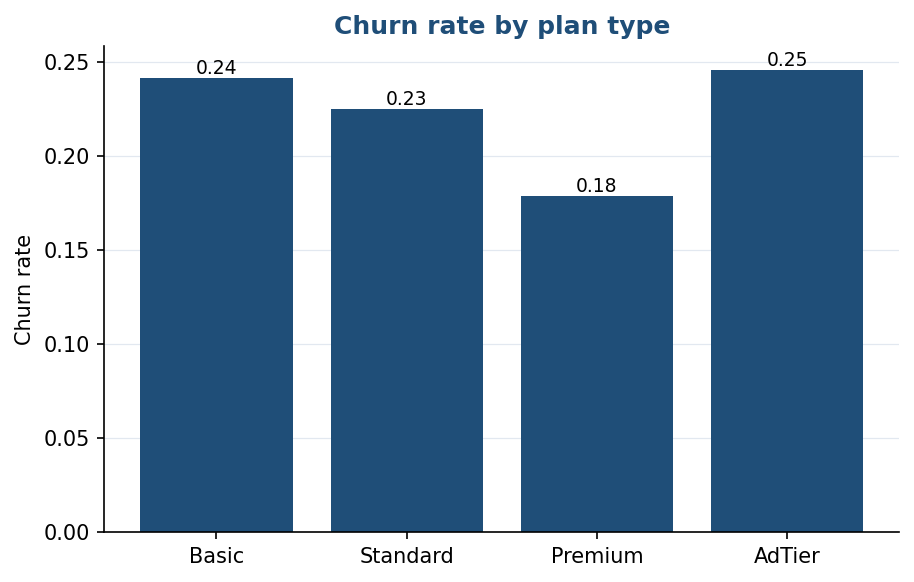

In [4]:
df.groupby('plan_type')['churn'].mean().reindex(['Basic','Standard','Premium','AdTier']).plot.bar()
plt.title('Churn rate by plan type'); plt.tight_layout(); plt.show()

### Feature distributions

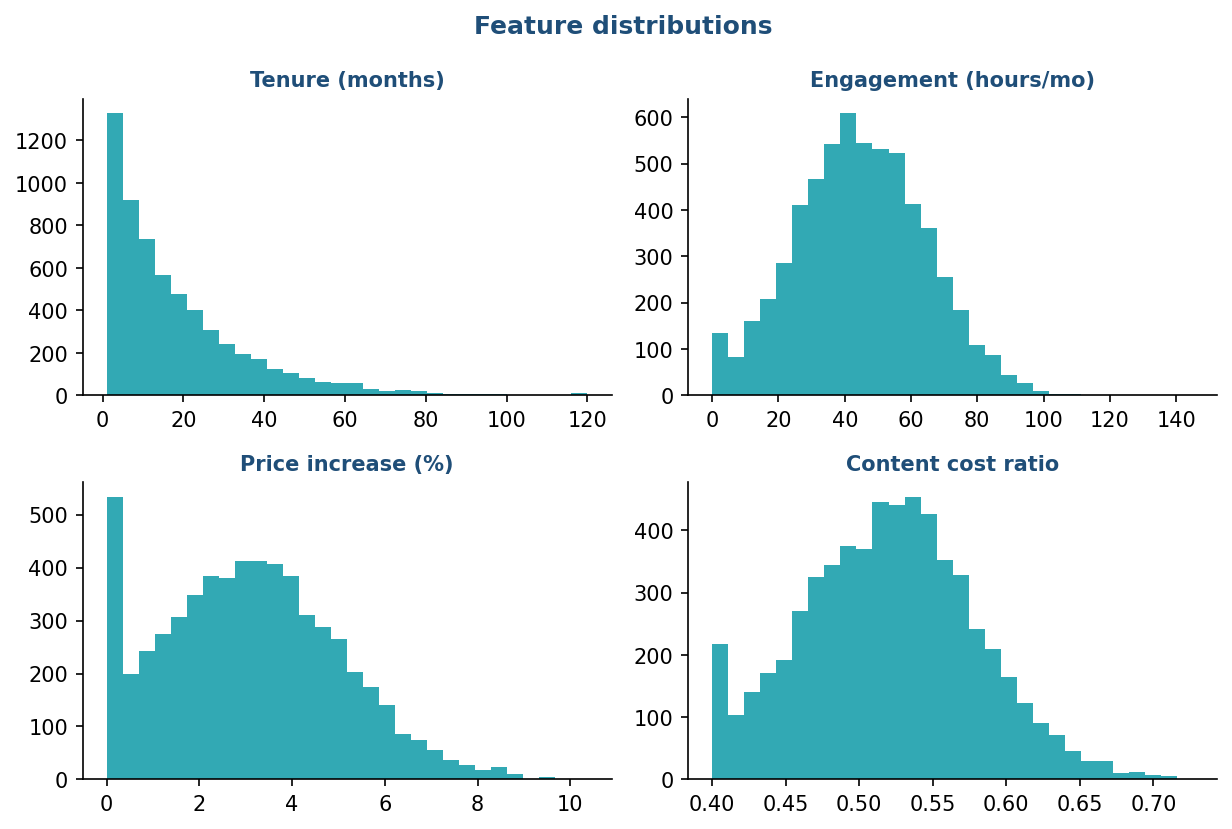

In [5]:
fig,axes=plt.subplots(2,2,figsize=(9,6))
for ax,c in zip(axes.ravel(),['tenure_months','engagement_hours','price_increase_pct','content_cost_ratio']):
    ax.hist(df[c],bins=30); ax.set_title(c)
plt.tight_layout(); plt.show()

**Takeaway.** The dataset is clean and balanced enough to model. Churn sits near 22 percent, and the features that vary most across subscribers, tenure, engagement, and price changes, are the ones the churn model leans on in Notebook 3.